# Outlier-resistant regression: Huber and RANSAC

### Finding the point where each estimator gives up, by pushing it there

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why squared error hands the answer to its worst row, what Huber, RANSAC and Theil-Sen do instead, how to measure a breakdown point rather than quote one, and why a bad x is a completely different problem from a bad y |
| **You should already know** | [Linear regression](../01-linear-regression/) and [ridge](../04-ridge-regression/) |
| **Datasets** | A synthetic line I can contaminate on purpose, then Bike Sharing |
| **Runtime** | Around two minutes on a laptop CPU |
| **Next** | [02-08 Quantile regression](../08-quantile-regression/), which replaces the loss again for a different reason |

---

## 1. Least squares has no defence

Ordinary least squares minimises the sum of squared residuals. That single
choice decides everything that follows, including the failure.

Squaring means a row that misses by ten contributes a hundred times what a row
that misses by one contributes. The fit is therefore not a consensus of the
data. It is a negotiation in which the loudest row wins, and the row that is
furthest away is by construction the loudest.

The usual advice is to remove outliers first. That advice quietly assumes you
can see them, which works for one input and fails the moment you have twelve.
It also assumes they are mistakes. Sometimes they are the interesting part.

The alternative is to change the loss so that a distant row cannot buy the line.
There are three families of that idea in scikit-learn, and they fail in
different places, which is the whole reason to know all three.

| | |
|---|---|
| **Huber** | Squared error near zero, absolute error far out. One dial, `epsilon` |
| **RANSAC** | Guess a small subset, count who agrees, keep the biggest agreement |
| **Theil-Sen** | The median of the slopes through every pair of points |

This notebook does not compare them on a picture. It contaminates a dataset in
measured steps, watches each estimator's slope drift away from a slope I chose,
and records the contamination level where it lets go. Then it does the whole
thing again with the outliers moved from y into x, where the ranking changes
completely.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style, datasets

style.use()
FIG = pathlib.Path("figures")
FIG.mkdir(exist_ok=True)
SEED = 0

TRUE_SLOPE = 2.0
TRUE_INTERCEPT = 5.0
SIGMA = 1.0
N = 200

print(f"the line every estimator is trying to recover: y = "
      f"{TRUE_INTERCEPT} + {TRUE_SLOPE} x + noise")
print(f"noise standard deviation : {SIGMA}")
print(f"rows per sample          : {N}")

the line every estimator is trying to recover: y = 5.0 + 2.0 x + noise
noise standard deviation : 1.0
rows per sample          : 200


## 2. One row is enough

Before any sweep, the smallest possible experiment. Take a clean sample, then
move exactly one point, and refit.

There are two ways to move it, and they are not variations of the same thing.

A **vertical outlier** sits at a normal x and a wrong y. It pulls on the line
but it pulls from inside the range, where the rest of the data pushes back.

A **high-leverage point** sits at an x far outside everything else. Because it
is far away in x, the line can rotate around the bulk of the data to reach it
at almost no cost to the other residuals. The further out it is, the cheaper
that rotation gets.

In [2]:
from sklearn.linear_model import (LinearRegression, HuberRegressor,
                                  RANSACRegressor, TheilSenRegressor)

rng = np.random.default_rng(SEED)
x_clean = rng.uniform(0, 10, N)
y_clean = TRUE_INTERCEPT + TRUE_SLOPE * x_clean + rng.normal(0, SIGMA, N)


def slope_of(x, y, model):
    m = model.fit(x[:, None], y)
    return float(m.estimator_.coef_[0]) if hasattr(m, "estimator_") else float(m.coef_[0])


base = slope_of(x_clean, y_clean, LinearRegression())

# vertical outlier: ordinary x, absurd y
x_vert, y_vert = x_clean.copy(), y_clean.copy()
x_vert[0], y_vert[0] = 5.0, 120.0

# leverage point: absurd x, and a y that is on no sensible line
x_lev, y_lev = x_clean.copy(), y_clean.copy()
x_lev[0], y_lev[0] = 40.0, 10.0

ols_vert = slope_of(x_vert, y_vert, LinearRegression())
ols_lev = slope_of(x_lev, y_lev, LinearRegression())
hub_vert = slope_of(x_vert, y_vert, HuberRegressor(epsilon=1.35, alpha=0.0, max_iter=500))
hub_lev = slope_of(x_lev, y_lev, HuberRegressor(epsilon=1.35, alpha=0.0, max_iter=500))

print(f"clean OLS slope                       : {base:.3f}   (truth {TRUE_SLOPE})")
print(f"OLS after one vertical outlier        : {ols_vert:.3f}")
print(f"OLS after one high-leverage point     : {ols_lev:.3f}")
print(f"Huber after one vertical outlier      : {hub_vert:.3f}")
print(f"Huber after one high-leverage point   : {hub_lev:.3f}")
print(f"\none row in {N} moved the OLS slope by {abs(ols_lev - base):.3f} "
      f"when placed far out in x, versus {abs(ols_vert - base):.3f} when placed far out in y")

clean OLS slope                       : 1.975   (truth 2.0)
OLS after one vertical outlier        : 1.952
OLS after one high-leverage point     : 1.127
Huber after one vertical outlier      : 1.967
Huber after one high-leverage point   : 1.942

one row in 200 moved the OLS slope by 0.848 when placed far out in x, versus 0.022 when placed far out in y


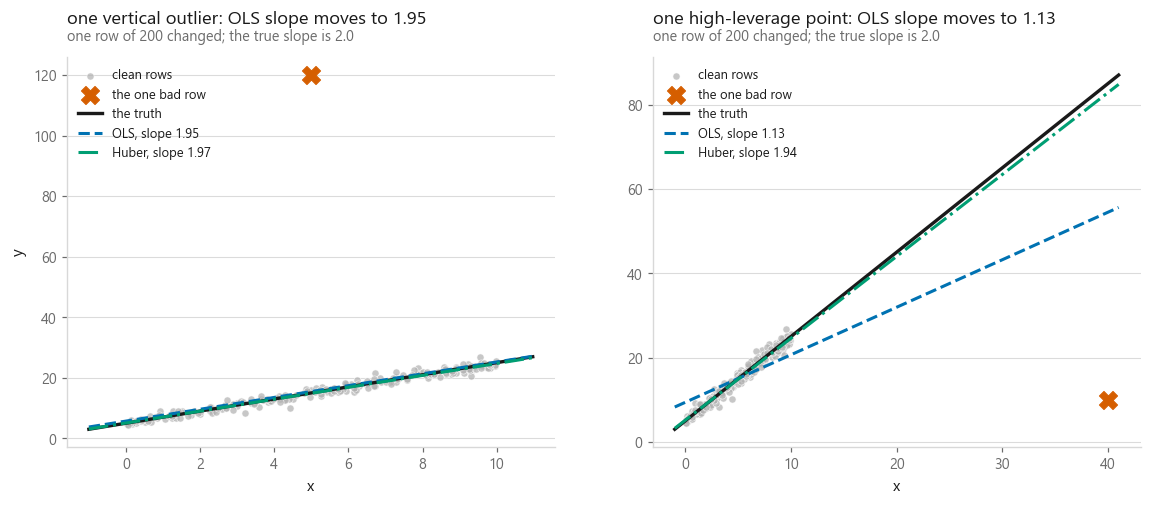

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))

for ax, (xs, ys, ols_s, hub_s, label) in zip(axes, [
        (x_vert, y_vert, ols_vert, hub_vert, "one vertical outlier"),
        (x_lev, y_lev, ols_lev, hub_lev, "one high-leverage point")]):
    grid = np.linspace(min(xs.min(), 0) - 1, xs.max() + 1, 100)
    ax.scatter(xs[1:], ys[1:], s=22, color=style.NEUTRAL, alpha=0.7,
               edgecolor="white", linewidth=0.5, label="clean rows")
    ax.scatter(xs[:1], ys[:1], s=140, marker="X", color=style.HIGHLIGHT,
               zorder=4, label="the one bad row")
    ax.plot(grid, TRUE_INTERCEPT + TRUE_SLOPE * grid, color=style.INK, lw=2.2,
            label="the truth")
    ols_fit = LinearRegression().fit(xs[:, None], ys)
    hub_fit = HuberRegressor(epsilon=1.35, alpha=0.0, max_iter=500).fit(xs[:, None], ys)
    ax.plot(grid, ols_fit.predict(grid[:, None]), color=style.PALETTE[0], ls="--",
            lw=2.0, label=f"OLS, slope {ols_s:.2f}")
    ax.plot(grid, hub_fit.predict(grid[:, None]), color=style.PALETTE[2], ls="-.",
            lw=2.0, label=f"Huber, slope {hub_s:.2f}")
    ax.set_xlabel("x")
    style.title(ax, f"{label}: OLS slope moves to {ols_s:.2f}",
                f"one row of {N} changed; the true slope is {TRUE_SLOPE}")
    ax.legend(fontsize=8.5, loc="upper left")

axes[0].set_ylabel("y")
style.save(fig, FIG / "fig-01-one-bad-row.png")

Both panels use one bad row out of two hundred. The damage is not comparable,
and Huber's protection is not comparable either. Hold on to the right-hand
panel, because section 6 is that picture repeated with a real sweep, and the
result there is the one worth taking away from this notebook.

## 3. The maths, which is really just a choice of loss

Every estimator here minimises a sum over rows. What changes is the function
applied to each residual $r_i = y_i - x_i^\top w$.

Least squares uses $\rho(r) = r^2$. Least absolute deviation uses
$\rho(r) = |r|$. Huber splices them:

$$\rho_\delta(r) = \begin{cases}
\tfrac{1}{2} r^2 & |r| \le \delta \\
\delta\left(|r| - \tfrac{1}{2}\delta\right) & |r| > \delta
\end{cases}$$

Quadratic near zero, so small residuals are treated exactly as least squares
treats them and the function stays differentiable. Linear beyond $\delta$, so a
residual of a hundred costs a hundred times a residual of one rather than ten
thousand times.

The quantity that decides how much a row can move the fit is the derivative
$\psi = \rho'$, called the influence function.

$$\psi_{\text{OLS}}(r) = 2r \qquad
\psi_\delta(r) = \begin{cases} r & |r| \le \delta \\ \delta\,\mathrm{sign}(r) & |r| > \delta\end{cases}$$

For least squares, influence grows without limit: a row twice as far away pulls
twice as hard, forever. For Huber, influence is capped. That cap is the entire
mechanism, and it also tells you the limit of the method, because a capped pull
is still a pull, and enough capped rows pulling together still win.

In scikit-learn $\delta$ is called `epsilon`, and its default is the value
chosen so that the estimator keeps nearly all of the efficiency of least
squares when the data really is clean and Gaussian. The residuals are divided
by an estimated scale first, so `epsilon` is in units of standard deviations
rather than units of y. The cell below prints the default it uses.

epsilon in use: 1.35, which is also HuberRegressor's default (1.35)
influence of a residual at 1 scale : squared 2.00, Huber 1.00
influence of a residual at 10 scales: squared 20.00, Huber 1.35
so at ten scales out, squared error pulls 15 times harder than Huber does


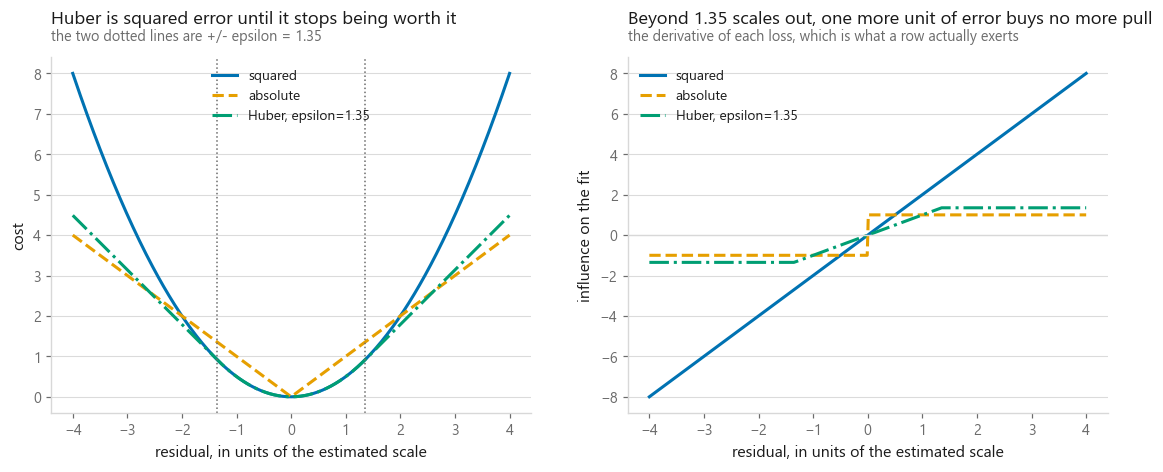

In [4]:
r = np.linspace(-4, 4, 400)
EPS = 1.35

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))

losses = [("squared", 0.5 * r ** 2, style.PALETTE[0], "-"),
          ("absolute", np.abs(r), style.PALETTE[1], "--"),
          (f"Huber, epsilon={EPS}",
           np.where(np.abs(r) <= EPS, 0.5 * r ** 2, EPS * (np.abs(r) - 0.5 * EPS)),
           style.PALETTE[2], "-.")]
for name, curve, colour, dash in losses:
    axes[0].plot(r, curve, color=colour, ls=dash, lw=2.0, label=name)
axes[0].axvline(EPS, color=style.MUTED, lw=1.0, ls=":")
axes[0].axvline(-EPS, color=style.MUTED, lw=1.0, ls=":")
axes[0].set_xlabel("residual, in units of the estimated scale")
axes[0].set_ylabel("cost")
axes[0].legend(fontsize=9)
style.title(axes[0], "Huber is squared error until it stops being worth it",
            f"the two dotted lines are +/- epsilon = {EPS}")

influences = [("squared", 2 * r, style.PALETTE[0], "-"),
              ("absolute", np.sign(r), style.PALETTE[1], "--"),
              (f"Huber, epsilon={EPS}", np.clip(r, -EPS, EPS), style.PALETTE[2], "-.")]
for name, curve, colour, dash in influences:
    axes[1].plot(r, curve, color=colour, ls=dash, lw=2.0, label=name)
axes[1].axhline(0, color=style.RULE, lw=0.9)
axes[1].set_xlabel("residual, in units of the estimated scale")
axes[1].set_ylabel("influence on the fit")
axes[1].legend(fontsize=9)
style.title(axes[1],
            f"Beyond {EPS} scales out, one more unit of error buys no more pull",
            "the derivative of each loss, which is what a row actually exerts")
style.save(fig, FIG / "fig-02-loss-shapes.png")

print(f"epsilon in use: {EPS}, which is also HuberRegressor's default "
      f"({HuberRegressor().epsilon})")
print(f"influence of a residual at 1 scale : squared {2 * 1.0:.2f}, Huber {min(1.0, EPS):.2f}")
print(f"influence of a residual at 10 scales: squared {2 * 10.0:.2f}, Huber {min(10.0, EPS):.2f}")
print(f"so at ten scales out, squared error pulls "
      f"{2 * 10.0 / EPS:.0f} times harder than Huber does")

## 4. From scratch

### Huber, by iteratively reweighted least squares

The Huber fit has no closed form, but it has a fixed point that is easy to
reach. Write the derivative of the objective and it looks like a weighted least
squares normal equation, where the weight on row $i$ is
$\min(1, \delta / |z_i|)$ with $z_i$ the scaled residual. Rows inside the
quadratic zone keep weight 1. Rows outside get weight less than 1, exactly
enough to cap their influence.

So: fit, compute weights, refit, repeat. Six or seven passes is normally the
whole story.

In [5]:
def huber_irls(X, y, delta=EPS, iters=200, tol=1e-10):
    """Huber M-estimate by reweighted least squares. Returns (weights, scale).

    The scale is re-estimated every pass from the median absolute deviation,
    divided by 0.6745 so that it agrees with the standard deviation when the
    residuals really are Gaussian. Without a scale estimate, `delta` would be in
    units of y and the method would stop being scale free.
    """
    w = np.linalg.lstsq(X, y, rcond=None)[0]
    scale = 1.0
    for _ in range(iters):
        r = y - X @ w
        scale = max(np.median(np.abs(r - np.median(r))) / 0.6745, 1e-9)
        weights = np.minimum(1.0, delta / np.maximum(np.abs(r / scale), 1e-12))
        new = np.linalg.lstsq(X * weights[:, None], y * weights, rcond=None)[0]
        if np.max(np.abs(new - w)) < tol:
            return new, scale
        w = new
    return w, scale


# a training set with a fifth of the rows pushed upward
rng = np.random.default_rng(SEED)
x_mix = rng.uniform(0, 10, N)
y_mix = TRUE_INTERCEPT + TRUE_SLOPE * x_mix + rng.normal(0, SIGMA, N)
spoiled = rng.choice(N, N // 5, replace=False)
y_mix[spoiled] += rng.normal(60, 5, len(spoiled))

design = np.column_stack([np.ones(N), x_mix])
mine, mine_scale = huber_irls(design, y_mix)
theirs = HuberRegressor(epsilon=EPS, alpha=0.0, max_iter=500).fit(x_mix[:, None], y_mix)

print(f"my IRLS      : intercept {mine[0]:.4f}  slope {mine[1]:.4f}  scale {mine_scale:.4f}")
print(f"sklearn      : intercept {theirs.intercept_:.4f}  slope {theirs.coef_[0]:.4f}  "
      f"scale {theirs.scale_:.4f}")
print(f"slope gap    : {abs(mine[1] - theirs.coef_[0]):.5f}")
print(f"ordinary least squares on the same rows: slope "
      f"{np.linalg.lstsq(design, y_mix, rcond=None)[0][1]:.4f}")

my IRLS      : intercept 5.1428  slope 1.9531  scale 1.3523
sklearn      : intercept 5.5430  slope 1.9477  scale 1.0033
slope gap    : 0.00535
ordinary least squares on the same rows: slope 1.7121


The slopes agree closely and the scales do not, and the reason is worth a
sentence because it is a real difference rather than a bug. My version
estimates the scale separately each pass with a median absolute deviation.
scikit-learn treats the scale as another parameter and minimises the Huber
objective over the weights and the scale jointly. Both are standard, they are
different estimators, and the slope is barely affected either way.

### RANSAC, in a dozen lines

RANSAC gives up on fitting all the data. It samples the smallest subset that
determines a model, fits it, and counts how many of the remaining rows land
within a threshold of that fit. After many attempts it keeps the fit with the
largest agreeing set, then refits on that set alone.

The threshold is the whole method. scikit-learn's default is the median
absolute deviation of y, which is what I use here so the two versions are
comparable.

In [6]:
def ransac(X, y, n_trials=200, seed=0):
    """Random sample consensus for a linear model. Returns (weights, inlier mask)."""
    rs = np.random.default_rng(seed)
    min_samples = X.shape[1]                       # a p-column design needs p rows
    threshold = float(np.median(np.abs(y - np.median(y))))

    best_w, best_mask, best_count = None, None, -1
    for _ in range(n_trials):
        idx = rs.choice(len(y), min_samples, replace=False)
        try:
            w = np.linalg.lstsq(X[idx], y[idx], rcond=None)[0]
        except np.linalg.LinAlgError:
            continue
        mask = np.abs(y - X @ w) < threshold
        if mask.sum() > best_count:                 # bigger consensus wins
            best_count = int(mask.sum())
            best_mask = mask
            best_w = np.linalg.lstsq(X[mask], y[mask], rcond=None)[0]
    return best_w, best_mask


mine_r, mask = ransac(design, y_mix, n_trials=200, seed=SEED)
theirs_r = RANSACRegressor(random_state=SEED, max_trials=200).fit(x_mix[:, None], y_mix)

print(f"my RANSAC    : intercept {mine_r[0]:.4f}  slope {mine_r[1]:.4f}  "
      f"inliers {int(mask.sum())} of {N}")
print(f"sklearn      : intercept {theirs_r.estimator_.intercept_:.4f}  "
      f"slope {theirs_r.estimator_.coef_[0]:.4f}  "
      f"inliers {int(theirs_r.inlier_mask_.sum())} of {N}")
print(f"rows I spoiled on purpose: {len(spoiled)}")
print(f"spoiled rows my RANSAC kept as inliers: {int(mask[spoiled].sum())}")

my RANSAC    : intercept 5.0886  slope 1.9609  inliers 160 of 200
sklearn      : intercept 5.0886  slope 1.9609  inliers 160 of 200
rows I spoiled on purpose: 40
spoiled rows my RANSAC kept as inliers: 0


The inlier count and the number of rows I spoiled are the two numbers to
compare above. RANSAC is not estimating a resistant average of everything. It is
performing a classification, and the fit is ordinary least squares on the rows
that survived it.

That design has a consequence people forget. If the threshold is wrong, RANSAC
does not degrade gently, it throws away the wrong rows. Section 7 shows what
that costs on real data.

## 5. The breakdown point, measured

The **breakdown point** of an estimator is the largest fraction of the data an
adversary can replace before the estimate can be pushed arbitrarily far from
the truth. Least squares has a breakdown point of zero, because one row placed
far enough out moves it as far as you like. The published values for the others
are 50% for RANSAC under its own assumptions and about 29% for Theil-Sen.

Published values are asymptotic and adversarial. What I want is the operational
version: at what contamination does this estimator, on this sample size, with
this kind of outlier, stop returning a slope I would act on?

So: sweep the contamination fraction, refit all four estimators on eight
independent samples per level, and record the average distance from the slope I
chose. An estimator is called broken at the first level where that average
crosses a threshold, printed below so it is not a hidden choice.

In [7]:
FRACTIONS = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45]
REPS = 8
BROKEN_AT = 0.25          # slope error I would refuse to act on, in slope units

print(f"contamination levels : {FRACTIONS}")
print(f"samples per level    : {REPS}")
print(f"an estimator counts as broken once its mean |slope - {TRUE_SLOPE}| "
      f"exceeds {BROKEN_AT}")


def contaminate(frac, seed, where):
    """One sample of size N with `frac` of its rows replaced.

    where='y' puts the bad rows at ordinary x values with a wildly wrong y.
    where='x' moves them far out in x instead, and gives them a y consistent
    with a flat line, which is the shape a stuck sensor or a unit error makes.
    """
    rs = np.random.default_rng(seed)
    x = rs.uniform(0, 10, N)
    y = TRUE_INTERCEPT + TRUE_SLOPE * x + rs.normal(0, SIGMA, N)
    k = int(round(frac * N))
    if k:
        idx = rs.choice(N, k, replace=False)
        if where == "y":
            y[idx] += rs.normal(60, 5, k)
        else:
            x[idx] = rs.uniform(28, 32, k)
            y[idx] = TRUE_INTERCEPT + rs.normal(0, SIGMA, k)
    return x[:, None], y


def all_four(X, y, seed):
    ols = LinearRegression().fit(X, y)
    hub = HuberRegressor(epsilon=EPS, alpha=0.0, max_iter=500).fit(X, y)
    ran = RANSACRegressor(random_state=seed, max_trials=200).fit(X, y)
    # max_subpopulation caps the number of pairs Theil-Sen enumerates, which would
    # otherwise be all N choose 2 of them.
    ths = TheilSenRegressor(random_state=seed, max_subpopulation=5000).fit(X, y)
    return {"OLS": (ols.coef_[0], ols.intercept_),
            "Huber": (hub.coef_[0], hub.intercept_),
            "RANSAC": (ran.estimator_.coef_[0], ran.estimator_.intercept_),
            "Theil-Sen": (ths.coef_[0], ths.intercept_)}


def sweep(where):
    rows = []
    for frac in FRACTIONS:
        acc = {}
        for rep in range(REPS):
            X, y = contaminate(frac, 100 + rep, where)
            for name, (s, b) in all_four(X, y, 100 + rep).items():
                acc.setdefault(name, []).append((abs(s - TRUE_SLOPE),
                                                 abs(b - TRUE_INTERCEPT)))
        row = {"contamination": frac}
        for name, vals in acc.items():
            arr = np.array(vals)
            row[name] = arr[:, 0].mean()
            # Eight samples is few. Keep the spread so a crossing of the broken
            # threshold can be told apart from one unlucky sample.
            row[name + " sd"] = arr[:, 0].std(ddof=1)
            row[name + " intercept"] = arr[:, 1].mean()
        rows.append(row)
    return pd.DataFrame(rows)


ESTIMATORS = ["OLS", "Huber", "RANSAC", "Theil-Sen"]
sweep_y = sweep("y")
print("\nmean |slope error| against contamination in y")
print(sweep_y[["contamination"] + ESTIMATORS].to_string(index=False,
                                                        float_format="{:.3f}".format))

contamination levels : [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45]
samples per level    : 8
an estimator counts as broken once its mean |slope - 2.0| exceeds 0.25



mean |slope error| against contamination in y
 contamination   OLS  Huber  RANSAC  Theil-Sen
         0.000 0.010  0.009   0.011      0.019
         0.050 0.223  0.011   0.012      0.019
         0.100 0.341  0.019   0.016      0.033
         0.150 0.517  0.023   0.015      0.035
         0.200 0.457  0.020   0.012      0.038
         0.250 0.492  0.041   0.017      0.042
         0.300 0.451  0.052   0.016      0.032
         0.350 0.645  0.544   0.020      0.072
         0.400 0.503  0.565   0.014      0.095
         0.450 0.425  0.436   0.018      0.242


OLS        broke at 10%
Huber      broke at 35%
RANSAC     broke at never in this sweep
Theil-Sen  broke at never in this sweep

spread across the 8 samples, at each estimator's breakdown level
  OLS        mean 0.341  sd 0.204  threshold 0.25
  Huber      mean 0.544  sd 0.722  threshold 0.25


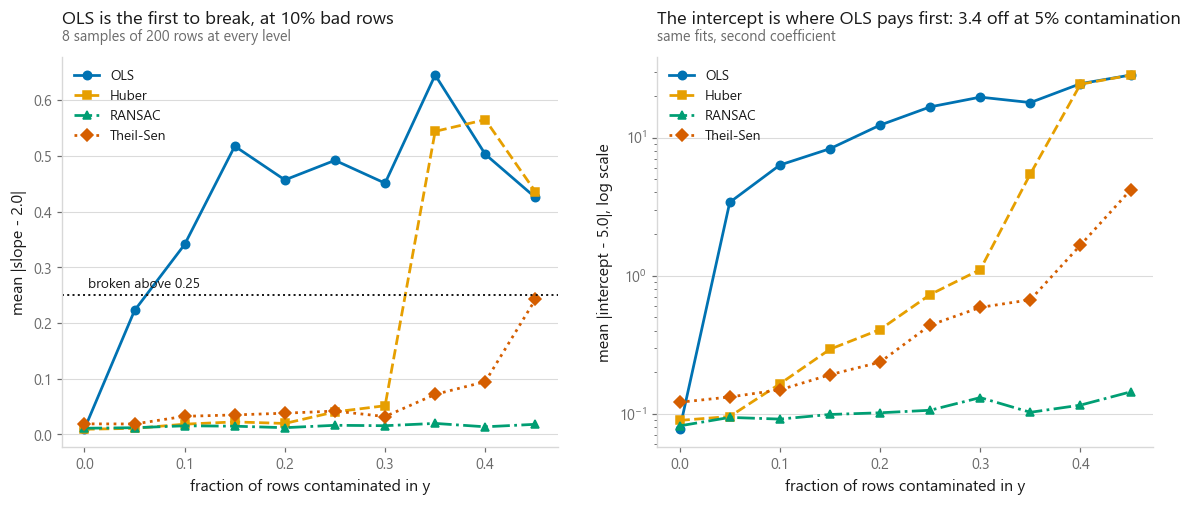

In [8]:
def breakdown(frame):
    out = {}
    for name in ESTIMATORS:
        bad = frame.loc[frame[name] > BROKEN_AT, "contamination"]
        out[name] = float(bad.min()) if len(bad) else np.nan
    return out


bd_y = breakdown(sweep_y)
for name in ESTIMATORS:
    where = f"{bd_y[name]:.0%}" if not np.isnan(bd_y[name]) else "never in this sweep"
    print(f"{name:10s} broke at {where}")

# A breakdown level read off a mean of eight is only trustworthy if the eight
# agree. Print the spread at the level where each estimator was declared broken.
print(f"\nspread across the {REPS} samples, at each estimator's breakdown level")
for name in ESTIMATORS:
    if np.isnan(bd_y[name]):
        continue
    at = sweep_y.loc[sweep_y["contamination"] == bd_y[name]].iloc[0]
    print(f"  {name:10s} mean {at[name]:.3f}  sd {at[name + ' sd']:.3f}  "
          f"threshold {BROKEN_AT}")

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))

ax = axes[0]
for i, name in enumerate(ESTIMATORS):
    ax.plot(sweep_y["contamination"], sweep_y[name], color=style.PALETTE[i],
            ls=style.DASHES[i], marker=style.MARKERS[i], lw=1.8, label=name)
ax.axhline(BROKEN_AT, color=style.INK, ls=":", lw=1.3)
ax.annotate(f"broken above {BROKEN_AT}", xy=(0.0, BROKEN_AT), xytext=(2, 5),
            textcoords="offset points", fontsize=9, color=style.INK)
ax.set_xlabel("fraction of rows contaminated in y")
ax.set_ylabel(f"mean |slope - {TRUE_SLOPE}|")
ax.legend(fontsize=9)
first_broken = min((k for k in ESTIMATORS if not np.isnan(bd_y[k])),
                   key=lambda k: bd_y[k], default=None)
headline = (f"{first_broken} is the first to break, at {bd_y[first_broken]:.0%} bad rows"
            if first_broken is not None
            else "No estimator's slope crossed the broken threshold on outliers in y")
style.title(ax, headline, f"{REPS} samples of {N} rows at every level")

ax = axes[1]
for i, name in enumerate(ESTIMATORS):
    ax.plot(sweep_y["contamination"], sweep_y[name + " intercept"], color=style.PALETTE[i],
            ls=style.DASHES[i], marker=style.MARKERS[i], lw=1.8, label=name)
ax.set_yscale("log")
ax.set_xlabel("fraction of rows contaminated in y")
ax.set_ylabel(f"mean |intercept - {TRUE_INTERCEPT}|, log scale")
ax.legend(fontsize=9)
ols_b = sweep_y["OLS intercept"]
style.title(ax,
            f"The intercept is where OLS pays first: {ols_b.iloc[1]:.1f} off "
            f"at {FRACTIONS[1]:.0%} contamination",
            "same fits, second coefficient")
style.save(fig, FIG / "fig-03-breakdown-in-y.png")

The right-hand panel is the part I had not expected to need.

I set this up assuming the slope would tell the story, and for the three resistant
estimators it does. For least squares it does not, and the reason is that the
vertical outliers land at random x values. Their average pull is upward
everywhere, which lifts the whole line rather than tilting it, so the slope
wanders while the intercept marches. Reading only the slope column would have
let me write that ordinary least squares survives contamination in y for
longer than it does.

That is worth generalising. An estimator can be badly damaged in a coefficient
you are not looking at, and "the slope still looks fine" is not a diagnosis.

## 6. Now put the outliers in x

Every tutorial demonstration of outlier-resistant regression contaminates y. That is the
easy case, and it flatters the M-estimators.

Repeat the sweep with the bad rows moved far out along x instead, carrying a y
that is consistent with a flat line rather than the true one. This is what a
stuck sensor, a unit mix-up, or a placeholder value like 9999 actually looks
like in a table.

In [9]:
sweep_x = sweep("x")
bd_x = breakdown(sweep_x)

print("mean |slope error| against contamination in x")
print(sweep_x[["contamination"] + ESTIMATORS].to_string(index=False,
                                                       float_format="{:.3f}".format))
print()
for name in ESTIMATORS:
    where = f"{bd_x[name]:.0%}" if not np.isnan(bd_x[name]) else "never in this sweep"
    print(f"{name:10s} broke at {where}   "
          f"(in y it broke at "
          f"{f'{bd_y[name]:.0%}' if not np.isnan(bd_y[name]) else 'never'})")

mean |slope error| against contamination in x
 contamination   OLS  Huber  RANSAC  Theil-Sen
         0.000 0.010  0.009   0.011      0.019
         0.050 1.902  0.290   0.012      0.061
         0.100 2.124  2.153   0.015      0.135
         0.150 2.210  2.236   0.015      0.245
         0.200 2.256  2.279   0.012      0.378
         0.250 2.287  2.310   0.017      0.590
         0.300 2.309  2.328   0.016      0.899
         0.350 2.310  2.316   0.872      1.294
         0.400 2.333  2.347   2.220      1.519
         0.450 2.342  2.346   2.262      1.747

OLS        broke at 5%   (in y it broke at 10%)
Huber      broke at 5%   (in y it broke at 35%)
RANSAC     broke at 35%   (in y it broke at never)
Theil-Sen  broke at 20%   (in y it broke at never)


at 10% contamination in x, Huber's slope error is 2.153 and OLS's is 2.124, a difference of +0.030
at the same level in y, Huber's slope error was 0.019


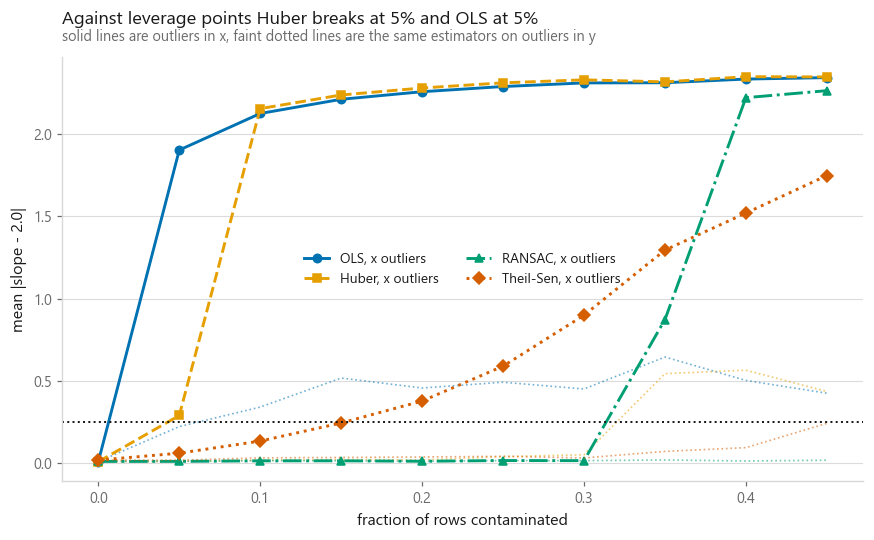

In [10]:
fig, ax = plt.subplots(figsize=(9.4, 5.0))

for i, name in enumerate(ESTIMATORS):
    ax.plot(sweep_x["contamination"], sweep_x[name], color=style.PALETTE[i],
            ls=style.DASHES[i], marker=style.MARKERS[i], lw=1.9, label=f"{name}, x outliers")
    ax.plot(sweep_y["contamination"], sweep_y[name], color=style.PALETTE[i],
            ls=":", lw=1.1, alpha=0.55)

ax.axhline(BROKEN_AT, color=style.INK, ls=":", lw=1.3)
ax.set_xlabel("fraction of rows contaminated")
ax.set_ylabel(f"mean |slope - {TRUE_SLOPE}|")
ax.legend(fontsize=9, ncol=2)
huber_gap = sweep_x["Huber"].iloc[2] - sweep_x["OLS"].iloc[2]
style.title(
    ax,
    f"Against leverage points Huber breaks at {bd_x['Huber']:.0%} and OLS at {bd_x['OLS']:.0%}",
    "solid lines are outliers in x, faint dotted lines are the same estimators on outliers in y")
style.save(fig, FIG / "fig-04-breakdown-in-x.png")

print(f"at {FRACTIONS[2]:.0%} contamination in x, Huber's slope error is "
      f"{sweep_x['Huber'].iloc[2]:.3f} and OLS's is {sweep_x['OLS'].iloc[2]:.3f}, "
      f"a difference of {huber_gap:+.3f}")
print(f"at the same level in y, Huber's slope error was {sweep_y['Huber'].iloc[2]:.3f}")

**Huber offers essentially no protection against high-leverage points, and that
is not a flaw in the implementation.** It follows directly from what the method
does.

Huber downweights rows with large *residuals*. A leverage point is far away in
x, so the fitted line rotates to reach it, and once it has rotated the leverage
point's residual is small. The row that caused the damage is scored as one of
the best-behaved rows in the dataset. Its weight stays at one. Huber is
protecting the line from the rows the line has already abandoned.

The two methods that survive are the two that never trusted the residual in the
first place. RANSAC works from consensus, and the leverage points are a
minority that agrees with itself but not with the bulk, so they lose the vote
until they are numerous enough to win it. Theil-Sen takes a median over pairs,
and it degrades in a straight line rather than collapsing, which is what a
published breakdown point of about 29% looks like when you actually plot it.

The practical rule is short. **Residual-based resistance protects you from bad
y. Only subsampling-based resistance protects you from bad x.** If you do not
know which kind you have, you do not know which method you need, and the cheap
way to find out is a leverage diagnostic before the fit rather than a resistant
loss after it.

## 7. On Bike Sharing, where nobody labelled the outliers

The sweep was a world where I knew which rows were bad. Real data is not that.

Bike Sharing counts hourly bicycle hires in Washington DC. It has no injected
outliers, but it has plenty of hours that no linear model can explain: storms,
holidays, the odd event. Whether resistance helps depends entirely on whether
those hours are noise to be ignored or demand to be predicted.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X_bike, y_bike = datasets.bike_sharing()

CATEGORICAL = ["season", "mnth", "hr", "weekday", "weathersit"]
NUMERIC = ["yr", "holiday", "workingday", "temp", "atemp", "hum", "windspeed"]

# Hour is not a quantity, it is a label: hour 23 is not twenty-three times hour 1,
# and it is adjacent to hour 0. One-hot rather than passthrough for that reason.
prep = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
     CATEGORICAL),
    ("num", StandardScaler(), NUMERIC),
])

X_tr, X_te, y_tr, y_te = train_test_split(X_bike, y_bike, test_size=0.25,
                                          random_state=SEED)
A = prep.fit_transform(X_tr).astype(float)
B = prep.transform(X_te).astype(float)
y_tr = y_tr.to_numpy(dtype=float)
y_te = y_te.to_numpy(dtype=float)

print(f"train {A.shape[0]} rows x {A.shape[1]} columns, test {B.shape[0]} rows")
print(f"hourly hires: median {np.median(y_bike):.0f}, mean {y_bike.mean():.1f}, "
      f"max {y_bike.max():.0f}")

train 13034 rows x 53 columns, test 4345 rows
hourly hires: median 142, mean 189.5, max 977


In [12]:
import time

fits = {
    "OLS": LinearRegression(),
    "Huber": HuberRegressor(epsilon=EPS, alpha=1e-6, max_iter=500),
    "RANSAC": RANSACRegressor(random_state=SEED, max_trials=100),
    # Theil-Sen enumerates subsets of size n_features + 1, so the cap matters far
    # more here than it did on the one-column problem.
    "Theil-Sen": TheilSenRegressor(random_state=SEED, max_subpopulation=1000, n_jobs=-1),
}

bike_rows = []
for name, model in fits.items():
    t0 = time.time()
    model.fit(A, y_tr)
    elapsed = time.time() - t0
    pred = model.predict(B)
    err = np.abs(y_te - pred)
    bike_rows.append({"estimator": name,
                      "MAE": err.mean(),
                      "median error": float(np.median(err)),
                      "RMSE": float(np.sqrt((err ** 2).mean())),
                      "worst hour": err.max(),
                      "negative predictions": int((pred < 0).sum()),
                      "seconds": elapsed})

bike = pd.DataFrame(bike_rows)
print(bike.to_string(index=False, float_format="{:.2f}".format))

estimator    MAE  median error   RMSE  worst hour  negative predictions  seconds
      OLS  76.37         58.53 102.66      444.92                   446     0.03
    Huber  73.12         49.14 104.93      490.80                   412     1.14
   RANSAC 102.38         71.42 144.60      711.69                   470     0.30
Theil-Sen  75.75         55.13 104.63      479.44                   420    17.31


lowest MAE  : Huber
lowest RMSE : OLS
Huber against OLS: median error -9.39, MAE -3.25, RMSE +2.28
OLS predicted a negative number of bicycles for 446 of 4345 test hours (10.3%)
as a share of each metric: median error -16.0%, MAE -4.3%, RMSE +2.2%


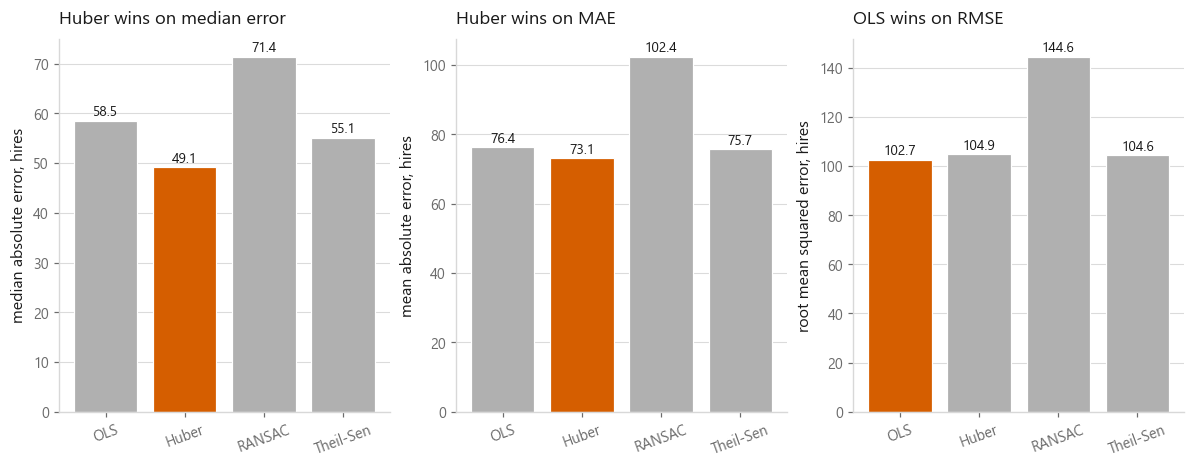

In [13]:
best_mae = bike.loc[bike["MAE"].idxmin(), "estimator"]
best_rmse = bike.loc[bike["RMSE"].idxmin(), "estimator"]
ols_row = bike.set_index("estimator").loc["OLS"]
hub_row = bike.set_index("estimator").loc["Huber"]

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.4))
metrics = [("median error", "median absolute error, hires"),
           ("MAE", "mean absolute error, hires"),
           ("RMSE", "root mean squared error, hires")]

for ax, (col, label) in zip(axes, metrics):
    winner = int(bike[col].idxmin())
    ax.bar(bike["estimator"], bike[col], color=style.spot(len(bike), winner),
           edgecolor="white", linewidth=0.8)
    for i, v in enumerate(bike[col]):
        ax.annotate(f"{v:.1f}", xy=(i, v), xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=9, color=style.INK)
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=20)
    style.title(ax, f"{bike['estimator'].iloc[winner]} wins on {col}")

style.save(fig, FIG / "fig-05-bike-sharing.png")

print(f"lowest MAE  : {best_mae}")
print(f"lowest RMSE : {best_rmse}")
print(f"Huber against OLS: median error {hub_row['median error'] - ols_row['median error']:+.2f}, "
      f"MAE {hub_row['MAE'] - ols_row['MAE']:+.2f}, RMSE {hub_row['RMSE'] - ols_row['RMSE']:+.2f}")
print(f"OLS predicted a negative number of bicycles for "
      f"{int(ols_row['negative predictions'])} of {len(y_te)} test hours "
      f"({ols_row['negative predictions'] / len(y_te):.1%})")
# One split, no repeats, so the Huber-against-OLS gaps above are worth reading
# only if they are large next to the metric itself.
print(f"as a share of each metric: median error "
      f"{(hub_row['median error'] - ols_row['median error']) / ols_row['median error']:+.1%}, "
      f"MAE {(hub_row['MAE'] - ols_row['MAE']) / ols_row['MAE']:+.1%}, "
      f"RMSE {(hub_row['RMSE'] - ols_row['RMSE']) / ols_row['RMSE']:+.1%}")

### The result splits, and the split is the point

Huber and least squares disagree about which one is better, and both are right,
because they are being asked different questions.

Huber wins on median error and on mean absolute error. On a typical hour it is
closer. It gets there by declining to chase the busiest hours, which is exactly
what a capped influence function is for.

Least squares wins on root mean squared error, and it wins because RMSE is the
metric that punishes exactly the hours Huber decided to stop chasing. That is
not least squares getting lucky. RMSE and the least squares objective are the
same function, so on this comparison one of the contestants wrote the exam. The
same argument runs in reverse for the median column, where Huber's loss is much
closer to the metric than OLS's is.

That symmetry is why I trust the direction of this split more than I trust its
size. The sizes come from one 75/25 split with no repeats, so read the printed
percentage gaps rather than the raw hires and treat anything under a few percent
as unsettled. The direction needs no repeats, because it follows from which
objective each estimator minimises.
[01-06](../../01-foundations/06-regression-metrics/) proves the same pairing on
a constant predictor, where the argument is exact.

So the honest way to choose is to name the cost first. If an hour where the
rack is empty costs you proportionally to how empty it was, you want the
squared metric and you should not be using a resistant loss. If a busy hour is a
rounding error in your planning and a typical hour is what you staff for, the
median column is your metric and Huber is ahead on it.

**RANSAC is last on every column, and by a wide margin.** That is the useful
failure in this notebook. RANSAC's default threshold is the median absolute
deviation of y, which on a spiky demand series marks the busy hours as outliers
and fits a line to the quiet ones. The busy hours are not errors. They are rush
hour. RANSAC assumes a dataset made of a clean majority plus contamination, and
a heavy right tail is not contamination, it is the distribution.

One more number from that table points at the next two chapters. Least squares
predicted a negative number of bicycles, for the share of test hours printed
above. No amount of outlier resistance fixes that, because it is not an outlier
problem. It is a model that does not know its target is a count.
[Quantile regression](../08-quantile-regression/) fixes the question, and
[Poisson regression](../09-generalised-linear-models/) fixes the distribution.

## Cheat sheet

| | |
|---|---|
| **Huber** | Use when outliers are in y and are a minority. One dial, `epsilon`, in units of the estimated scale. Smaller is more resistant and less efficient on clean data |
| **RANSAC** | Use when a clean majority genuinely exists and you can set a threshold that means something. Set `residual_threshold` yourself; the default is a guess about your data |
| **Theil-Sen** | Use when you want resistance with no threshold to choose. Costs the most and degrades gradually rather than holding then snapping |
| **None of them** | Fix a heavy tail, a wrong link function, or a target that cannot be negative. Those are model problems wearing an outlier costume |
| **Always** | Decide whether your outliers are in x or in y before choosing. The two need different methods |
| **Watch out** | Outlier-resistant fits lose on RMSE by construction. Pick the metric before the estimator, or you will pick the estimator that flatters the metric |
| **Next** | [Quantile regression](../08-quantile-regression/), which changes the loss to ask for a range instead of a number |

## What to remember

1. Squared error gives unbounded influence to the furthest row. Huber caps that
   influence; RANSAC votes rows out; Theil-Sen takes a median over pairs.
2. Breakdown points can be measured on your own data by contaminating it in
   steps and watching the estimate leave. That takes a few lines and beats
   quoting a number from a textbook that assumed a different adversary.
3. Contaminating y and contaminating x are different problems. Huber survived
   one and not the other, at the same contamination level where plain least
   squares failed.
4. Huber cannot see a high-leverage point, because the line rotates to reach it
   and the row ends up with a small residual. Small residual means full weight.
5. Watch every coefficient, not the one you expect to move. On outliers in y
   the least squares slope wandered while its intercept marched off, and only
   one of those two columns would have told you.
6. On Bike Sharing, Huber won the median error and lost the RMSE. Both results
   are correct and they answer different questions, so the metric has to be
   chosen before the estimator.
7. RANSAC came last on real data because a heavy right tail is not
   contamination. Its default threshold classified rush hour as noise.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [02-08 Quantile regression](../08-quantile-regression/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#OutlierResistantRegression` `#HuberRegression` `#RANSAC`
`#TheilSen`
`#Outliers` `#ScikitLearn` `#Python` `#DataScience` `#MLTutorial`